# 📊 KOSDAQ/US Screener + Deep-Learning Imputation (Jupyter/Colab)

## 목표
- 장기 윈도우(MA60, ATR14) 때문에 상장 초기 구간이 `NaN`으로 잘리는 문제를 **딥러닝 기반 보강(NumPy MLP)** 으로 완화
- `basis`: D / W-FRI / 2W-FRI / M 리샘플
- 상대강도(RS) 벤치마크: 한국 KQ11(코스닥)/KS11(코스피), 미국은 SPY/QQQ 권장
- **외생/내생 이벤트**를 CSV로 불러서 표시, 다중 종목 비교, 체크리스트형 BUY/SELL 신호

## 사고 과정 요약
1. 문제: 신규상장 종목은 주봉 기준 MA60/ATR이 오래 `NaN` → 기존 `dropna()`가 초반을 잘라버림  
2. 1차: `warmup="loose"`로 NaN 허용해 표시는 가능하게, 백테스트/검증은 `warmup="strict"`로 분리  
3. 2차(본 노트북): 후행 구간(지표가 존재)에서 **최근 k기간의 수익률/거래량/짧은MA/짧은ATR**로 **롱 윈도우 지표를 회귀 학습** → 초반 결측 구간에 **지표를 추정(impute)**  
   - 모델: **NumPy 구현 MLP** (외부 DL 프레임워크 불필요)
   - 결과는 `*_imp`와 `*_is_imputed` 플래그로 명시  
   - 당연히 **추정치**이므로, 전략 검증/실거래 전에는 **impute=off**로 한 번 더 점검 필요

## 빠른 사용 가이드
- 한국 종목: `"338220"` 같은 **6자리 숫자 티커**. 미국: `"AAPL"`, `"NVDA"` 등 티커.
- RS 벤치마크: 한국은 `rs_index_code="KQ11"`(코스닥) 또는 `"KS11"`, 미국은 `"SPY"`/`"QQQ"`.
- 이벤트 CSV 포맷(UTF-8): `date,label,etype,span`
  - `etype`: `exo`(외생) / `endo`(내생), `span`: 밴드폭(주)


# KOSDAQ Event-Driven Strategy — 최종 함수 파라미터 설명 & 사용자 가이드

아래는 노트북(v3)에서 “직접 쓰게 될” 최종 활용 함수들의 파라미터와 사용법을 정리한 문서다. 군더더기 없이 핵심만 적었다.

---

## 1) `load_events_news_csvs(path_exo, path_endo)`

외생(매크로/정책/전쟁 등)·내생(회사 특정 이슈) 이벤트 CSV를 읽어 하나의 이벤트 테이블로 합친다.

**파라미터**

| 이름          | 타입    | 설명                                           |
| ----------- | ----- | -------------------------------------------- |
| `path_exo`  | `str` | 외생 이벤트 CSV 경로 (예: `/events_ex.csv`) |
| `path_endo` | `str` | 내생 이벤트 CSV 경로 (예: `/events_in.csv`) |

**CSV 컬럼 기대치(유연 파서)**

* 날짜: `date`(권장) / `published_at` / `timestamp` / `time` / `created_at` 중 하나
* 텍스트/라벨: `label`(권장) / `title` / `headline` / `summary` / `text` 중 하나
* 가중치(선택): `weight` (없으면 `impact_score`/`importance`/`score`/`magnitude`/`confidence`/`certainty` 중 하나를 정규화)
* 방향/감성(선택): `polarity`(-1~1) 또는 `direction`/`sentiment`(“positive/bullish/up”=+1, “negative/bearish/down”=-1, 그 외=0)
* 기간(span, 선택): `span` (이벤트 영향이 지속되는 바 수치)

**반환**
`date, label, etype('exo'|'endo'), span, weight, polarity` 를 갖는 `DataFrame`.

**예시**

```python
events = load_events_news_csvs("/events_ex.csv", "/events_in.csv")
events = events[events["date"] >= "2020-01-01"]
```

---

## 2) `filter_events_by_strength(events_df, basis, mode, min_strength, q, top_k, merge_window_days)`

이벤트가 너무 많아 그래프가 지저분할 때, 기간별로 “강한 이벤트만” 추린다.

**파라미터**

| 이름                  |             타입 |        기본 | 설명                                         |
| ------------------- | -------------: | --------: | ------------------------------------------ |
| `events_df`         | `pd.DataFrame` |         — | `load_events_news_csvs` 결과                 |
| `basis`             |          `str` | `"W-FRI"` | 기간 단위: `"D"`, `"W-FRI"`, `"2W-FRI"`, `"M"` |
| `mode`              |          `str` |  `"topk"` | `"threshold"` | `"quantile"` | `"topk"`    |
| `min_strength`      |        `float` |     `0.3` | `mode="threshold"`일 때 강도 하한(0~1)           |
| `q`                 |        `float` |     `0.8` | `mode="quantile"`일 때 분위수(0~1)              |
| `top_k`             |          `int` |       `2` | `mode="topk"`일 때 기간·유형별 상위 K개              |
| `merge_window_days` |          `int` |       `2` | 근접한 날짜 이벤트 병합(더 강한 것만 유지)                  |

**반환**
강도 컬럼(`strength`)이 포함된 필터링된 이벤트 `DataFrame`.

**예시**

```python
ev_core = filter_events_by_strength(events, basis="W-FRI", mode="topk", top_k=2)
```

---

## 3) `compute_indicators(df_raw, basis, ma_windows, atr_n, rs_index_code, warmup)`

OHLCV를 지정 단위로 리샘플링하고 MA/ATR/OBV/상대강도(RS)를 만든다.

**파라미터**

| 이름              |             타입 |        기본 | 설명                                             |
| --------------- | -------------: | --------: | ---------------------------------------------- |
| `df_raw`        | `pd.DataFrame` |         — | `FinanceDataReader.DataReader(symbol)` 결과      |
| `basis`         |          `str` | `"W-FRI"` | `"D"`, `"W-FRI"`, `"2W-FRI"`, `"M"`            |
| `ma_windows`    |    `(int,int)` | `(20,60)` | 단기/중기 이동평균 창                                   |
| `atr_n`         |          `int` |      `14` | ATR 윈도우                                        |
| `rs_index_code` |  `str or None` |    `None` | 상대강도 비교 벤치마크. 코스닥이면 `"KQ11"` 권장, 미국은 `"SPY"` 등 |
| `warmup`        |          `str` | `"loose"` | `"loose"`: 핵심 결측만 제거, `"strict"`: 전 컬럼 결측 제거   |

> 일반적으로 직접 호출할 필요는 없다. 아래의 `plot_strategy_with_events`에서 자동 사용.

---

## 4) `EventRuleParams`

이벤트+기술 신호 규칙의 하이퍼파라미터 묶음.

**필드**

| 이름               |      타입 |      기본 | 설명                                             |
| ---------------- | ------: | ------: | ---------------------------------------------- |
| `m1`             |   `int` |    `20` | 단기 MA                                          |
| `m2`             |   `int` |    `60` | 중기 MA                                          |
| `alpha`          | `float` |   `1.0` | `E_event = alpha*E_endo + beta*E_exo` 의 내생 가중치 |
| `beta`           | `float` |   `0.5` | 위 식의 외생 가중치                                    |
| `gamma`          | `float` |   `0.5` | 진입점수: `S_entry = S_tech + gamma * E_event`     |
| `tau_buy`        |   `int` |     `4` | 매수 임계치(이 값 이상이면 BUY 후보)                        |
| `theta_on`       | `float` |  `0.10` | 외생 리스크-온 문턱 (이상이면 위험선호)                        |
| `theta_off`      | `float` | `-0.10` | 외생 리스크-오프 문턱 (이하면 위험회피)                        |
| `half_life_exo`  |   `int` |     `8` | 외생 이벤트 반감기(바 단위)                               |
| `half_life_endo` |   `int` |    `20` | 내생 이벤트 반감기(바 단위)                               |

---

## 5) `plot_strategy_with_events(...)`

단일 종목의 가격/지표/이벤트/신호를 한 번에 그린다. 내부에서 결측 임퓨팅(경량 MLP)과 신호 생성, 이벤트 스코어 결합까지 처리한다. **분석의 메인 진입점**.

**시그니처(핵심 파라미터만 표기)**

```python
plot_strategy_with_events(
  symbol: str,
  name: Optional[str] = None,
  basis: str = "W-FRI",
  ma_windows: Tuple[int,int] = (20,60),
  rs_index_code: Optional[str] = None,
  events_df: Optional[pd.DataFrame] = None,
  params: EventRuleParams = EventRuleParams(),
  use_imputed: bool = True,
  signal_type: str = "event",
  # 이벤트 표시 필터
  event_filter_mode: str = "topk",
  event_top_k: int = 2,
  event_q: float = 0.9,
  event_min_strength: float = 0.3,
  show_agg_bar: bool = True
) -> pd.DataFrame  # mix
```

**주요 파라미터 설명**

| 이름                                       | 설명                                                                                    |
| ---------------------------------------- | ------------------------------------------------------------------------------------- |
| `symbol`                                 | 티커(한국 6자리, 예: `"328130"` 루닛)                                                          |
| `name`                                   | 차트 제목에 표시할 이름                                                                         |
| `basis`                                  | 리샘플 기준 (`"D"`, `"W-FRI"`, `"2W-FRI"`, `"M"`)                                          |
| `ma_windows`                             | (단기,중기) MA 길이                                                                         |
| `rs_index_code`                          | 상대강도 비교 벤치마크(코스닥: `"KQ11"`)                                                           |
| `events_df`                              | `load_events_news_csvs` 결과. 없으면 이벤트 결합 없이 **기술 신호만** 가능 (`signal_type="tech"`로 변경 필요) |
| `params`                                 | `EventRuleParams` 인스턴스                                                                |
| `use_imputed`                            | 결측(상장 초기 등) 지표를 경량 MLP로 보간                                                            |
| `signal_type`                            | `"event"`: 이벤트+기술 결합 신호 / `"tech"`: 기술 신호만                                            |
| `event_filter_mode/top_k/q/min_strength` | 차트에 찍을 “대표 이벤트” 필터링 옵션                                                                |
| `show_agg_bar`                           | 기간별(외생/내생) 이벤트 합산 바 그래프 출력 여부                                                         |

**반환**
지표/신호/이벤트 스코어가 결합된 `DataFrame`(`mix`).
(컬럼 예: `Close, MA20, MA60, ATR, ATR%, OBV, RS, EntryScore, BUY_sig, SELL_sig, E_exo, E_endo, E_event, S_entry, RiskOn, RiskOff, BUY_sig2, SELL_sig2` …)

**예시**

```python
params = EventRuleParams(theta_on=0.10, tau_buy=4, gamma=0.5, beta=0.5)
mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk", event_top_k=2
)
```

---

## 6) `simulate_backtest_from_mix(mix, ...)`

`plot_strategy_with_events`가 만든 `mix`를 받아 **다음 바 체결** 가정으로 모의 백테스트를 수행한다.

**시그니처(핵심 파라미터만 표기)**

```python
simulate_backtest_from_mix(
  mix: pd.DataFrame,
  basis: str = "W-FRI",
  exec_at: str = "open",
  use_event_signals: bool = True,
  fee_bps: float = 10.0,
  slippage_bps: float = 5.0,
  use_position_sizing: bool = True,
  atr_floor: float = 0.01,
  risk_scale: float = 1.0,
  atr_stop_mult: Optional[float] = None
) -> (pd.DataFrame, dict)
```

**파라미터 설명**

| 이름                    |              타입 |        기본 | 설명                                                                           |
| --------------------- | --------------: | --------: | ---------------------------------------------------------------------------- |
| `mix`                 |  `pd.DataFrame` |         — | `plot_strategy_with_events` 반환값                                              |
| `basis`               |           `str` | `"W-FRI"` | 리샘플 기준(수익률 연환산 기준 계산에 사용)                                                    |
| `exec_at`             |           `str` |  `"open"` | 신호 다음 바의 `"open"` 또는 `"close"` 가격 체결 가정                                      |
| `use_event_signals`   |          `bool` |    `True` | `True`: `BUY_sig2/SELL_sig2` 사용(이벤트+기술), `False`: `BUY_sig/SELL_sig` 사용(기술만) |
| `fee_bps`             |         `float` |    `10.0` | 수수료(bps)                                                                     |
| `slippage_bps`        |         `float` |     `5.0` | 슬리피지(bps)                                                                    |
| `use_position_sizing` |          `bool` |    `True` | 포지션 사이징 활성화 (`weight ∝ S_entry / ATR%`)                                      |
| `atr_floor`           |         `float` |    `0.01` | ATR% 하한(과도한 레버리지 방지)                                                         |
| `risk_scale`          |         `float` |     `1.0` | 최종 포지션 상한 조정(0~1)                                                            |
| `atr_stop_mult`       | `float or None` |    `None` | `N*ATR` 추적 손절. 예: `atr_stop_mult=3.0`                                        |

**반환**

* 결과 프레임 `res` (`ret, pnl, pos, equity`)
* 성과 딕셔너리 `perf` (`CAGR, Sharpe, MaxDD, #Trades, WinRate, AnnVol, LastEquity`)

**예시**

```python
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True, fee_bps=10, slippage_bps=5,
    use_position_sizing=True, atr_floor=0.01,
    risk_scale=1.0, atr_stop_mult=3.0
)
```

---

## 7) (참고) `aggregate_events_by_period(events_df, basis, signed)`

기간별(외생/내생) 이벤트 강도를 합산하여 막대 차트용 데이터 생성.

**파라미터**

| 이름          |        기본 | 설명                             |
| ----------- | --------: | ------------------------------ |
| `events_df` |         — | 이벤트 DF                         |
| `basis`     | `"W-FRI"` | 그룹핑 단위                         |
| `signed`    |    `True` | 부호 유지 합산(True) / 절댓값 합산(False) |

**반환**
`period, etype, strength` 컬럼의 `DataFrame`.

---

## 8) (참고) 결측 임퓨팅 `impute_indicators_deep(...)`

상장 초기 등의 결측 지표(예: `MA60`, `ATR%`)를 경량 MLP로 추정.
대부분 `plot_strategy_with_events(..., use_imputed=True)`로 자동 수행되며, 직접 호출할 필요는 드물다.

---


In [71]:
## 0) 환경 준비 / 패키지 설치
!pip -q install pandas numpy finance-datareader

In [72]:
## Library import

import math
from typing import Dict, Tuple, Optional

import io, sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import FinanceDataReader as fdr
from typing import List, Tuple, Dict, Optional, Union
from dataclasses import dataclass

In [73]:

# Colab 한글폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 설정 후 세션 재시작

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [74]:
import matplotlib.pyplot as plt


plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

import warnings
warnings.filterwarnings("ignore")

In [75]:

START_DATE = "2020-01-01"
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지 (폰트는 환경에 맞게 별도 설정)


# 공통 유틸 & 리샘플/지표(MA/ATR/OBV/RS)

In [97]:
def _parse_dt(x, fallback=None):
    if x is None:
        return pd.to_datetime(fallback) if fallback is not None else None
    return pd.to_datetime(x)


def ensure_dtindex(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'Date' in df.columns: df = df.set_index('Date')
        else: raise ValueError("No DatetimeIndex and no 'Date' column.")
    df.index = pd.to_datetime(df.index)
    return df.sort_index()

def resample_ohlcv(df: pd.DataFrame, basis: str="D") -> pd.DataFrame:
    # basis: "D" | "W-FRI" | "2W-FRI" | "M"
    df = ensure_dtindex(df)
    if basis == "D":
        return df[['Open','High','Low','Close','Volume']].dropna(how='any').copy()
    if basis in ["W-FRI","2W-FRI","M"]:
        o = df['Open'].resample(basis).first()
        h = df['High'].resample(basis).max()
        l = df['Low' ].resample(basis).min()
        c = df['Close'].resample(basis).last()
        v = df['Volume'].resample(basis).sum()
        out = pd.concat([o,h,l,c,v], axis=1)
        out.columns = ['Open','High','Low','Close','Volume']
        return out.dropna(how="any")
    raise ValueError("basis must be 'D','W-FRI','2W-FRI','M'")

def rolling_mean(s: pd.Series, w:int, minp:int=1) -> pd.Series:
    return s.rolling(w, min_periods=minp).mean()

def atr(df: pd.DataFrame, n:int=14, minp:int=1) -> pd.Series:
    h,l,c = df['High'], df['Low'], df['Close']
    pc = c.shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.rolling(n, min_periods=minp).mean()

def obv(df: pd.DataFrame) -> pd.Series:
    direction = np.sign(df['Close'].diff().fillna(0))
    return (direction * df['Volume']).cumsum()

def rel_strength(stock: pd.DataFrame, index_df: pd.DataFrame) -> pd.Series:
    s = stock['Close'].pct_change()
    i = index_df['Close'].pct_change()
    ref = pd.concat([s,i], axis=1, join='inner').dropna()
    return ref.iloc[:,0] - ref.iloc[:,1]

def guess_benchmark(symbol: str) -> str:
    # 간단 휴리스틱: 숫자 6자리면 KOSDAQ, 아니면 미국
    if symbol.isdigit() and len(symbol)==6: return "KQ11"
    return "SPY"

def compute_indicators(df_raw: pd.DataFrame,
                       basis: str="W-FRI",
                       ma_windows: Tuple[int,int]=(20,60),
                       atr_n:int=14,
                       rs_index_code: Optional[str]=None,
                       warmup: str="loose") -> pd.DataFrame:
    ohlc = resample_ohlcv(df_raw, basis)
    m1, m2 = ma_windows
    out = ohlc.copy()
    out[f"MA{m1}"] = rolling_mean(out['Close'], m1, minp=1)
    out[f"MA{m2}"] = rolling_mean(out['Close'], m2, minp=1)
    out["ATR"] = atr(out, atr_n, minp=1)
    out["ATR%"] = out["ATR"] / out["Close"]
    out["OBV"] = obv(out)

    bench_code = rs_index_code or guess_benchmark(str(df_raw.columns.name or ""))
    idx = fdr.DataReader(bench_code, start=str(out.index.min().date()))
    idx_r = resample_ohlcv(idx, basis)
    out["RS"] = rel_strength(out, idx_r).reindex(out.index)

    if warmup == "strict": return out.dropna()
    return out.dropna(subset=["Close"])


# 신호(체크리스트) 생성

In [77]:
def make_signals_from_tab(tab: pd.DataFrame, m1:int=20, m2:int=60) -> pd.DataFrame:
    t = tab.copy()
    t["OBV_slope10"] = t["OBV"].diff(10)
    t["RS_8_sum"] = t["RS"].rolling(8, min_periods=1).sum()
    t["ATRmin26"] = t["ATR%"].rolling(26, min_periods=1).min()

    t["ATR_calm"] = (t["ATR%"] <= t["ATRmin26"]*1.1).astype(int)
    t["Trend_OK"] = ((t["Close"] > t[f"MA{m1}"]) & (t[f"MA{m1}"] > t[f"MA{m2}"])).astype(int)
    t["OBV_pos"]  = (t["OBV_slope10"] > 0).astype(int)
    t["RS_pos"]   = (t["RS_8_sum"] > 0).astype(int)

    t["EntryScore"] = t["Trend_OK"] + t["OBV_pos"] + t["RS_pos"] + t["ATR_calm"]
    t["BUY_sig"]    = (t["EntryScore"] >= 4).astype(int)

    below_ma1 = (t["Close"] < t[f"MA{m1}"]).astype(int)
    t["BelowMA1_2bars"] = (below_ma1.rolling(2, min_periods=2).sum() == 2).astype(int)

    q80 = t["ATR%"].rolling(26, min_periods=10).quantile(0.8)
    t["ATR_hot"] = (t["ATR%"] > q80).astype(int)

    price_hh = t["Close"] > t["Close"].rolling(20, min_periods=1).max().shift(1)
    obv_hh   = t["OBV"]   > t["OBV"].rolling(20,   min_periods=1).max().shift(1)
    t["OBV_div_minus"] = ((price_hh) & (~obv_hh)).astype(int)

    t["SELL_sig"] = ((t["BelowMA1_2bars"]==1) | (t["OBV_div_minus"]==1) | (t["ATR_hot"]==1)).astype(int)
    return t


# 이벤트 CSV 로드 + 외생/내생 표시

In [78]:
def _map_direction_to_polarity(s: pd.Series) -> pd.Series:
    v = s.astype(str).str.lower().str.strip()
    v = v.map({"pos":"positive","neg":"negative"}).fillna(v)
    return (v.map({
        "positive":1.0,"bullish":1.0,"up":1.0,
        "negative":-1.0,"bearish":-1.0,"down":-1.0,
        "neutral":0.0,"mixed":0.0
    }).fillna(0.0).astype(float))

def _robust_events_loader(path: str, etype_fixed: str) -> pd.DataFrame:
    raw = pd.read_csv(path)
    # date: 다양한 컬럼 허용 + UTC 파싱 후 tz 제거(naive)
    def _parse_date_col(df: pd.DataFrame) -> pd.Series:
        for col in ["date", "published_at", "timestamp", "time", "created_at"]:
            if col in df.columns:
                d = pd.to_datetime(df[col], errors="coerce", utc=True)
                if d.notna().any():
                    return d
        return pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns, UTC]")

    dts = _parse_date_col(raw)
    dts = dts.dt.tz_convert("UTC").dt.tz_localize(None)  # tz-naive로

    # label
    for col in ["label","title","headline","summary","text"]:
        if col in raw.columns:
            label = raw[col].astype(str); break
    else:
        label = pd.Series([""]*len(raw), index=raw.index, dtype=str)

    # span
    span = pd.to_numeric(raw["span"], errors="coerce") if "span" in raw.columns else pd.Series(0, index=raw.index)

    # weight: impact_score > importance > score > ...
    if "weight" in raw.columns:
        weight = pd.to_numeric(raw["weight"], errors="coerce")
    else:
        cand = None
        for c in ["impact_score","importance","score","magnitude","confidence","certainty"]:
            if c in raw.columns:
                cand = pd.to_numeric(raw[c], errors="coerce"); break
        weight = cand if cand is not None else pd.Series(1.0, index=raw.index, dtype=float)

    # [0,1] 로버스트 정규화
    if weight.min() >= 0 and weight.max() <= 1.5:
        weight = weight.clip(0,1)
    else:
        lo, hi = weight.quantile(0.01), weight.quantile(0.99)
        weight = ((weight - lo) / (hi - lo if hi>lo else 1.0)).clip(0,1)
    weight = weight.fillna(1.0)

    # polarity
    if "polarity" in raw.columns:
        polarity = pd.to_numeric(raw["polarity"], errors="coerce").clip(-1,1)
    elif "direction" in raw.columns:
        polarity = _map_direction_to_polarity(raw["direction"])
    elif "sentiment" in raw.columns:
        polarity = _map_direction_to_polarity(raw["sentiment"])
    else:
        polarity = pd.Series(0.0, index=raw.index, dtype=float)

    out = pd.DataFrame({
        "date": dts,                # tz-naive 보장
        "label": label,
        "etype": etype_fixed,       # 'exo' or 'endo'
        "span": pd.to_numeric(span, errors="coerce").fillna(0).astype(int),
        "weight": weight.astype(float),
        "polarity": polarity.fillna(0.0).astype(float),
        "source": path
    }).dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    return out

def load_events_news_csvs(path_exo: str, path_endo: str) -> pd.DataFrame:
    exo  = _robust_events_loader(path_exo,  "exo")
    endo = _robust_events_loader(path_endo, "endo")
    out = (pd.concat([exo, endo], ignore_index=True)
             .sort_values(["date","etype","label","source"])
             .drop_duplicates(subset=["date","etype","label"], keep="first")
             .reset_index(drop=True))
    return out

def _normalize_events_df(events_df: Optional[pd.DataFrame]) -> pd.DataFrame:
    if events_df is None:
        return pd.DataFrame(columns=["date","label","etype","span","weight","polarity"])
    df = events_df.copy()
    if "date" not in df.columns or "etype" not in df.columns:
        raise ValueError("events_df must include 'date' and 'etype'")
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
    df["date"] = df["date"].dt.tz_convert("UTC").dt.tz_localize(None)  # tz-naive
    for col, default, typ in [("span",0,int), ("weight",1.0,float), ("polarity",0.0,float)]:
        if col not in df.columns: df[col] = default
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default).astype(typ)
    df["etype"] = df["etype"].str.lower().str.strip()
    df = df[df["etype"].isin(["exo","endo"])].sort_values("date").reset_index(drop=True)
    return df


# 이벤트 스코어 계산(지수감쇠/스팬) + 기술결합 신호 + 오더

In [79]:
def _bars_from_span(span: int, basis: str) -> int:
    if span <= 0: return 0
    if basis == "D":      return span
    if basis == "W-FRI":  return span
    if basis == "2W-FRI": return max(1, span//2)
    if basis == "M":      return max(1, span//4)
    return span

def _score_series(index: pd.DatetimeIndex, events_df: pd.DataFrame,
                  etype: str, basis: str, half_life: int) -> pd.Series:
    if getattr(index, "tz", None) is not None:
        index = index.tz_convert("UTC").tz_localize(None)
    s = pd.Series(0.0, index=index)
    if events_df is None or events_df.empty: return s
    df = events_df[events_df["etype"] == etype].copy()
    if df.empty: return s
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
    df["date"] = df["date"].dt.tz_convert("UTC").dt.tz_localize(None)

    rho = np.power(0.5, 1.0 / max(1, half_life))
    for _, r in df.iterrows():
        d0 = pd.to_datetime(r["date"])
        w  = float(r["weight"]) * float(r["polarity"])
        if w == 0.0: continue
        mask = index >= d0
        if not mask.any(): continue
        start = np.flatnonzero(mask)[0]
        span_bars = _bars_from_span(int(r["span"]), basis)
        if span_bars > 0:
            end = min(start + span_bars, len(index))
            s.iloc[start:end] += w
            k0 = end
        else:
            k0 = start
        if k0 < len(index):
            n = np.arange(0, len(index) - k0)
            s.iloc[k0:] += w * (rho ** n)
    return s

def attach_event_scores(tab: pd.DataFrame, events_df: Optional[pd.DataFrame], basis: str,
                        half_life_exo: int = 8, half_life_endo: int = 20,
                        alpha: float = 1.0, beta: float  = 0.5) -> pd.DataFrame:
    ev = _normalize_events_df(events_df)
    E_exo  = _score_series(tab.index, ev, "exo",  basis, half_life_exo)
    E_endo = _score_series(tab.index, ev, "endo", basis, half_life_endo)
    out = tab.copy()
    out["E_exo"]   = E_exo
    out["E_endo"]  = E_endo
    out["E_event"] = alpha*E_endo + beta*E_exo
    return out

@dataclass
class EventRuleParams:
    m1: int = 20
    m2: int = 60
    alpha: float = 1.0  # endo weight
    beta: float  = 0.5  # exo weight
    gamma: float = 0.5  # event → entry 가중
    tau_buy: int = 4    # 진입 임계(tech 0..4)
    theta_on: float  = 0.10  # Risk-ON (E_exo >= theta_on)
    theta_off: float = -0.10 # Risk-OFF (E_exo <= theta_off)
    half_life_exo: int  = 8
    half_life_endo: int = 20

def make_signals_with_events(tab: pd.DataFrame,
                             events_df: Optional[pd.DataFrame],
                             basis: str = "W-FRI",
                             params: EventRuleParams = EventRuleParams()) -> pd.DataFrame:
    base = make_signals_from_tab(tab, m1=params.m1, m2=params.m2)
    mix  = attach_event_scores(base, events_df, basis=basis,
                               half_life_exo=params.half_life_exo,
                               half_life_endo=params.half_life_endo,
                               alpha=params.alpha, beta=params.beta)
    mix["S_tech"]  = (mix["Trend_OK"] + mix["OBV_pos"] + mix["RS_pos"] + mix["ATR_calm"]).astype(float)
    mix["S_entry"] = mix["S_tech"] + params.gamma * mix["E_event"]
    mix["RiskOn"]  = (mix["E_exo"] >= params.theta_on).astype(int)
    mix["RiskOff"] = (mix["E_exo"] <= params.theta_off).astype(int)
    mix["BUY_sig2"]  = ((mix["RiskOn"]==1) & (mix["S_entry"] >= params.tau_buy)).astype(int)
    mix["SELL_sig2"] = ((mix["SELL_sig"]==1) | (mix["RiskOff"]==1)).astype(int)
    return mix


# 이벤트 강도/필터/집계(일·주·2주·월 지원)

In [80]:
def compute_event_strength(df: pd.DataFrame,
                           weight_col: str = "weight",
                           polarity_col: str = "polarity",
                           norm: bool = True) -> pd.Series:
    w = pd.to_numeric(df.get(weight_col, 1.0), errors="coerce").fillna(1.0)
    p = pd.to_numeric(df.get(polarity_col, 0.0), errors="coerce").fillna(0.0)
    s = w * p.abs()
    if norm:
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        s = ((s - lo) / (hi - lo if hi > lo else 1.0)).clip(0, 1)
    return s

def filter_events_by_strength(events_df: pd.DataFrame,
                              basis: str = "W-FRI",
                              mode: str = "topk",
                              min_strength: float = 0.3,
                              q: float = 0.8,
                              top_k: int = 2,
                              merge_window_days: int = 2) -> pd.DataFrame:
    if events_df is None or events_df.empty:
        return events_df

    ev = events_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    # 강도 계산(0~1 정규화)
    def _strength(df: pd.DataFrame) -> pd.Series:
        w = pd.to_numeric(df.get("weight", 1.0), errors="coerce").fillna(1.0)
        p = pd.to_numeric(df.get("polarity", 0.0), errors="coerce").fillna(0.0)
        s = w * p.abs()
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        return ((s - lo) / (hi - lo if hi > lo else 1.0)).clip(0, 1)
    ev["strength"] = _strength(ev)

    # 가까운 날짜 이벤트 병합(강한 것 우선)
    if merge_window_days and merge_window_days > 0:
        ev = ev.sort_values("date").reset_index(drop=True)
        keep = []
        for i, r in ev.iterrows():
            if not keep:
                keep.append(i); continue
            dt_days = (r["date"] - ev.loc[keep[-1], "date"]).days
            if dt_days <= merge_window_days:
                if r["strength"] > ev.loc[keep[-1], "strength"]:
                    keep[-1] = i
            else:
                keep.append(i)
        ev = ev.iloc[keep].reset_index(drop=True)

    # 그룹별(기간 x etype)로 핵심 이벤트 선택
    def _select_group(g: pd.DataFrame) -> pd.DataFrame:
        if mode == "threshold":
            return g[g["strength"] >= float(min_strength)]
        elif mode == "quantile":
            thr = g["strength"].quantile(float(q)) if len(g) else 1.0
            return g[g["strength"] >= thr]
        elif mode == "topk":
            return g.nlargest(int(top_k), "strength")
        else:
            raise ValueError("mode must be 'threshold'|'quantile'|'topk'")

    grouped = ev.groupby([pd.Grouper(key="date", freq=basis), "etype"], group_keys=True).apply(_select_group)

    # ✅ 핵심 수정: reset_index 전에 기존 컬럼의 'date'/'etype'을 제거
    if isinstance(grouped, pd.DataFrame):
        dup_cols = [c for c in ("date", "etype") if c in grouped.columns]
        if dup_cols:
            grouped = grouped.drop(columns=dup_cols)

    # 이제 인덱스의 date/etype을 컬럼으로 안전하게 삽입
    out = (grouped.reset_index(level=[0, 1], drop=False)
                 .reset_index(drop=True))

    out = out.sort_values(["date", "etype", "strength"], ascending=[True, True, False])

    # 시각화용 period(막대 시작점)
    if basis == "D":
        out["period"] = out["date"].dt.to_period("D").dt.to_timestamp()
    else:
        out["period"] = out["date"].dt.to_period(basis.split("-")[0]).dt.to_timestamp()
    return out

def aggregate_events_by_period(events_df: pd.DataFrame,
                               basis: str = "W-FRI",
                               signed: bool = True) -> pd.DataFrame:
    if events_df is None or events_df.empty:
        return pd.DataFrame(columns=["period","etype","strength"])
    ev = events_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    w = pd.to_numeric(ev.get("weight", 1.0), errors="coerce").fillna(1.0)
    p = pd.to_numeric(ev.get("polarity", 0.0), errors="coerce").fillna(0.0)
    val = w * (p if signed else p.abs())
    lo, hi = val.quantile(0.01), val.quantile(0.99)
    val = (val - lo) / (hi - lo if hi > lo else 1.0)
    ev["val"] = val
    agg = (ev.groupby([pd.Grouper(key="date", freq=basis), "etype"])["val"]
             .sum()
             .reset_index()
             .rename(columns={"val":"strength"})
             .sort_values("date"))
    agg["period"] = agg["date"]
    return agg[["period","etype","strength"]]


# 멀티 비교(옵션)

In [81]:
def normalize_symbols(symbols: Union[List[str], Dict[str,str], List[Tuple[str,str]]]) -> List[Tuple[str,str]]:
    out = []
    if isinstance(symbols, dict):
        for name, tic in symbols.items(): out.append((tic, name))
    elif isinstance(symbols, list):
        if symbols and isinstance(symbols[0], (tuple, list)) and len(symbols[0])==2:
            for tic, name in symbols: out.append((tic, name))
        else:
            for tic in symbols: out.append((tic, tic))
    else:
        raise ValueError("symbols must be list/dict or list of (ticker,name)")
    return out

def _normalize_series(s: pd.Series, how: Optional[str]):
    if how is None: return s
    if how == "rebased":
        first = s.dropna().iloc[0]
        return s * (100.0 / first) if first != 0 else s
    if how == "zscore":
        m, sd = s.mean(), s.std(ddof=0)
        return (s - m) / sd if sd and sd!=0 else s*0
    raise ValueError("normalize must be None/'rebased'/'zscore'")

def plot_multi_compare(symbols, basis="W-FRI", field="ATR%", ma_for_overlay=None, rs_index_code=None, normalize=None):
    pairs = normalize_symbols(symbols)
    plt.figure(figsize=(12,6))
    for tic, label in pairs:
        df = fdr.DataReader(tic, start=START_DATE)
        tab = compute_indicators(df, basis=basis, rs_index_code=rs_index_code)
        y = _normalize_series(tab[field], normalize)
        plt.plot(tab.index, y, label=f"{label}({tic}) {field}{'|'+normalize if normalize else ''}")
        if ma_for_overlay and field=="Close":
            y_ma = _normalize_series(tab[f"MA{ma_for_overlay}"], normalize)
            plt.plot(tab.index, y_ma, label=f"{label} MA{ma_for_overlay}")
    plt.title(f"Multi Compare: {field} [{basis}] (normalize={normalize})")
    plt.legend(); plt.tight_layout(); plt.show()


# 임퓨트(상장 초기 NaN 보강; 경량 MLP)

In [82]:
@dataclass
class MLPConfig:
    hidden: int = 32
    hidden2: int = 0
    lr: float = 1e-3
    epochs: int = 1000
    l2: float = 1e-4
    batch_size: Optional[int] = None
    seed: int = 42

class MLPRegressorNP:
    def __init__(self, input_dim: int, cfg: MLPConfig):
        self.cfg = cfg
        rng = np.random.default_rng(cfg.seed)
        self.W1 = rng.normal(0, 0.05, size=(input_dim, cfg.hidden))
        self.b1 = np.zeros((cfg.hidden,))
        if cfg.hidden2 > 0:
            self.W2 = rng.normal(0, 0.05, size=(cfg.hidden, cfg.hidden2))
            self.b2 = np.zeros((cfg.hidden2,))
            self.W3 = rng.normal(0, 0.05, size=(cfg.hidden2, 1))
            self.b3 = np.zeros((1,))
        else:
            self.W2 = None; self.b2 = None
            self.W3 = rng.normal(0, 0.05, size=(cfg.hidden, 1))
            self.b3 = np.zeros((1,))
        # Adam states
        self.m = [np.zeros_like(self.W1), np.zeros_like(self.b1)]
        self.v = [np.zeros_like(self.W1), np.zeros_like(self.b1)]
        if cfg.hidden2 > 0:
            self.m += [np.zeros_like(self.W2), np.zeros_like(self.b2)]
            self.v += [np.zeros_like(self.W2), np.zeros_like(self.b2)]
        self.m += [np.zeros_like(self.W3), np.zeros_like(self.b3)]
        self.v += [np.zeros_like(self.W3), np.zeros_like(self.b3)]
        self.t = 0
        self.x_mu = self.x_sd = self.y_mu = self.y_sd = None

    @staticmethod
    def _relu(x): return np.maximum(0, x)

    def _forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = self._relu(Z1)
        if self.cfg.hidden2 > 0:
            Z2 = A1 @ self.W2 + self.b2
            A2 = self._relu(Z2)
            yhat = A2 @ self.W3 + self.b3
            cache = (X, Z1, A1, Z2, A2, yhat)
        else:
            yhat = A1 @ self.W3 + self.b3
            cache = (X, Z1, A1, None, None, yhat)
        return yhat, cache

    def _backward(self, cache, y, yhat):
        l2 = self.cfg.l2
        X, Z1, A1, Z2, A2, _ = cache
        N = X.shape[0]
        dy = (yhat - y) / N
        grads = {}
        if self.cfg.hidden2 > 0:
            grads['W3'] = A2.T @ dy + l2*self.W3
            grads['b3'] = dy.sum(axis=0)
            dA2 = dy @ self.W3.T
            dZ2 = dA2 * (Z2 > 0)
            grads['W2'] = A1.T @ dZ2 + l2*self.W2
            grads['b2'] = dZ2.sum(axis=0)
            dA1 = dZ2 @ self.W2.T
        else:
            grads['W3'] = A1.T @ dy + l2*self.W3
            grads['b3'] = dy.sum(axis=0)
            dA1 = dy @ self.W3.T
        dZ1 = dA1 * (Z1 > 0)
        grads['W1'] = X.T @ dZ1 + l2*self.W1
        grads['b1'] = dZ1.sum(axis=0)
        return grads

    def _adam_update(self, params, grads):
        self.t += 1
        lr = self.cfg.lr
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        plist = ['W1','b1'] + (['W2','b2'] if self.cfg.hidden2>0 else []) + ['W3','b3']
        for i, p in enumerate(plist):
            g = grads[p]
            self.m[i] = beta1*self.m[i] + (1-beta1)*g
            self.v[i] = beta2*self.v[i] + (1-beta1)*(g*g)
            mhat = self.m[i] / (1 - beta1**self.t)
            vhat = self.v[i] / (1 - beta2**self.t)
            params[p] -= lr * mhat / (np.sqrt(vhat)+eps)

    def _standardize_fit(self, X, y):
        self.x_mu = X.mean(axis=0, keepdims=True); self.x_sd = X.std(axis=0, keepdims=True)+1e-8
        self.y_mu = y.mean(axis=0, keepdims=True); self.y_sd = y.std(axis=0, keepdims=True)+1e-8

    def _standardize(self, X, y=None):
        Xn = (X - self.x_mu) / self.x_sd
        if y is None: return Xn, None
        yn = (y - self.y_mu) / self.y_sd
        return Xn, yn

    def _destandardize(self, yhat_n):
        return yhat_n * self.y_sd + self.y_mu

    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float).reshape(-1,1)
        self._standardize_fit(X,y)
        Xn, yn = self._standardize(X,y)
        params = {'W1':self.W1,'b1':self.b1}
        if self.cfg.hidden2 > 0: params.update({'W2':self.W2,'b2':self.b2})
        params.update({'W3':self.W3,'b3':self.b3})
        N = Xn.shape[0]; bs = self.cfg.batch_size or N
        for _ in range(self.cfg.epochs):
            for i in range(0, N, bs):
                xb, yb = Xn[i:i+bs], yn[i:i+bs]
                yhat, cache = self._forward(xb)
                grads = self._backward(cache, yb, yhat)
                self._adam_update(params, grads)
        self.W1, self.b1 = params['W1'], params['b1']
        if self.cfg.hidden2 > 0: self.W2, self.b2 = params['W2'], params['b2']
        self.W3, self.b3 = params['W3'], params['b3']

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        Xn, _ = self._standardize(X)
        yhat_n, _ = self._forward(Xn)
        return self._destandardize(yhat_n).ravel()

def make_features(tab: pd.DataFrame, k:int=10) -> pd.DataFrame:
    df = tab.copy()
    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['log_vol'] = np.log(df['Volume'].replace(0, np.nan)).fillna(method='ffill')
    feats = {}
    for j in range(1, k+1):
        feats[f"ret_lag{j}"] = df['log_ret'].shift(j)
        feats[f"vol_lag{j}"] = (df['log_vol'] - df['log_vol'].shift(j))
    feats = pd.DataFrame(feats, index=df.index)
    feats['MA10'] = df['Close'].rolling(10, min_periods=1).mean()
    atr7 = atr(df[['Open','High','Low','Close','Volume']].copy(), 7, minp=1)
    feats['ATR7%'] = (atr7 / df['Close'])
    return feats

def impute_indicators_deep(tab_loose: pd.DataFrame,
                           target_cols: List[str] = ["MA60","ATR%"],
                           k:int=10,
                           mlp_cfg: Optional[MLPConfig] = None) -> pd.DataFrame:
    mlp_cfg = mlp_cfg or MLPConfig(hidden=32, hidden2=0, lr=5e-3, epochs=1000, l2=1e-4, seed=42)
    out = tab_loose.copy()
    feats = make_features(out, k=k)
    for tgt in target_cols:
        y = out[tgt].copy()
        mask_train = y.notna() & feats.notna().all(axis=1)
        mask_pred  = y.isna()  & feats.notna().all(axis=1)
        if mask_train.sum() < max(50, feats.shape[1]*5):
            out[f"{tgt}_imp"] = out[tgt].fillna(out[tgt].rolling(5, min_periods=1).mean())
            out[f"{tgt}_is_imputed"] = out[tgt].isna().astype(int)
            continue
        X_train = feats.loc[mask_train].values
        y_train = y.loc[mask_train].values.reshape(-1,1)
        model = MLPRegressorNP(input_dim=X_train.shape[1], cfg=mlp_cfg)
        model.fit(X_train, y_train)
        out[f"{tgt}_imp"] = out[tgt]
        if mask_pred.any():
            X_pred = feats.loc[mask_pred].values
            y_hat = model.predict(X_pred)
            out.loc[mask_pred, f"{tgt}_imp"] = y_hat
        out[f"{tgt}_is_imputed"] = out[tgt].isna().astype(int)
    return out


In [95]:
import re

# 인덱스 코드 찾아주는 함수
# 캐시로 반복 호출 비용 절감
_AUTO_BENCH_CACHE = {}

def auto_benchmark(symbol: str) -> str:
    """
    티커(심볼)만으로 적절한 상대강도 벤치마크 코드를 추정.
    - 한국 6자리 숫자: KOSPI → KS11, KOSDAQ/KONEX → KQ11
    - 미국: NASDAQ 상장 → IXIC, 그 외(NYSE/AMEX/기타) → SPY
    - 위에서 못 찾으면 글로벌 기본값 SPY
    """
    sym = str(symbol).strip()
    if sym in _AUTO_BENCH_CACHE:
        return _AUTO_BENCH_CACHE[sym]

    # 1) 한국 6자리 코드
    if re.fullmatch(r"\d{6}", sym):
        try:
            krx = fdr.StockListing('KRX')
            row = krx.loc[krx['Code'] == sym]
            if not row.empty:
                market = (row['Market'].iloc[0] or "").upper()
                if 'KOSPI' in market:
                    bench = 'KS11'   # KOSPI 지수
                elif 'KOSDAQ' in market or 'KONEX' in market:
                    bench = 'KQ11'   # KOSDAQ 지수
                else:
                    bench = 'KQ11'   # 기본: 코스닥
                _AUTO_BENCH_CACHE[sym] = bench
                return bench
        except Exception:
            pass
        _AUTO_BENCH_CACHE[sym] = 'KQ11'
        return 'KQ11'

    # 2) 미국/기타 알파벳 심볼
    #    - 나스닥 상장: IXIC, 그 외(뉴욕/아멕스/모름): SPY
    try:
        for us_ex in ['NASDAQ', 'NYSE', 'AMEX']:
            try:
                lst = fdr.StockListing(us_ex)
                if not lst.empty and (lst['Symbol'] == sym).any():
                    if us_ex == 'NASDAQ':
                        _AUTO_BENCH_CACHE[sym] = 'IXIC'  # 나스닥 종합지수
                        return 'IXIC'
                    else:
                        _AUTO_BENCH_CACHE[sym] = 'SPY'   # S&P500 ETF 대용
                        return 'SPY'
            except Exception:
                continue
    except Exception:
        pass

    # 3) 최종 기본값
    _AUTO_BENCH_CACHE[sym] = 'SPY'
    return 'SPY'


# 플롯(핵심 이벤트만 수직선·집계바 지원)

In [118]:
def _draw_events(ax, events_df, basis, filter_mode="topk", top_k=2, q=0.9, min_strength=0.3):
    if events_df is None or events_df.empty:
        return
    ev_core = filter_events_by_strength(
        events_df, basis=basis, mode=filter_mode,
        min_strength=min_strength, q=q, top_k=top_k, merge_window_days=2
    )
    ymax = ax.get_ylim()[1]
    for _, r in ev_core.iterrows():
        d = pd.to_datetime(r["date"])
        ls = "--" if r.get("etype") == "exo" else ":"
        ax.axvline(d, linestyle=ls, alpha=0.6)
        lab = str(r.get("label",""))
        if lab:
            ax.text(d, ymax, f" {lab}", rotation=90, va="top", fontsize=8)


def plot_strategy_with_events(
    symbol: str,
    name: Optional[str] = None,
    basis: str = "W-FRI",
    ma_windows: Tuple[int, int] = (20, 60),
    rs_index_code: Optional[str] = None,
    events_df: Optional[pd.DataFrame] = None,
    params: EventRuleParams = EventRuleParams(),
    use_imputed: bool = True,
    signal_type: str = "event",                 # "event" | "tech"
    event_filter_mode: str = "topk",            # "topk" | "quantile" | "threshold"
    event_top_k: int = 2,
    event_q: float = 0.9,
    event_min_strength: float = 0.3,
    show_agg_bar: bool = True,
    # 날짜 범위/안정화
    start_date: Optional[Union[str, pd.Timestamp]] = None,
    end_date: Optional[Union[str, pd.Timestamp]] = None,
    warmup_days: int = 0,
    # 보조 패널(아래쪽 개별 패널)
    show_obv: bool = False,
    show_atr: bool = False,
    show_rs: bool = False,
    # 메인 차트 우측축 오버레이
    overlay_atr: bool = True,
    overlay_obv: str = "zscore",                # "none" | "zscore" | "minmax"
    obv_window: int = 60
) -> pd.DataFrame:
    """
    단일 종목의 가격/지표/이벤트/신호를 시각화하고 결합 테이블(mix)을 반환.

    - start_date/end_date를 지정하면 해당 구간만 분석 (warmup_days만큼 앞 구간을 더 가져와 계산 안정화)
    - 메인 차트: Close, MA(2개), BUY/SELL 마커, 이벤트 수직선 + (옵션) ATR%/정규화 OBV 우측축 오버레이
    - 보조 차트: 이벤트 스코어(E_exo/E_endo/S_entry) 및 옵션 개별 패널(OBV/ATR/RS)
    - 범례는 좌측 상단 하나로 통합 (우측축 범례 제거)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import FinanceDataReader as fdr
    import re

    # ---------- 헬퍼 ----------
    def _parse_dt(x, fallback=None):
        if x is None:
            return pd.to_datetime(fallback) if fallback is not None else None
        return pd.to_datetime(x)

    def _norm_obv(series: pd.Series, mode: str = "zscore", win: int = 60) -> pd.Series:
        s = pd.to_numeric(series, errors="coerce")
        if mode.lower() == "zscore":
            m = s.rolling(win, min_periods=10).mean()
            v = s.rolling(win, min_periods=10).std()
            return (s - m) / v.replace(0, np.nan)
        if mode.lower() == "minmax":
            lo = s.rolling(win, min_periods=10).min()
            hi = s.rolling(win, min_periods=10).max()
            return (s - lo) / (hi - lo).replace(0, np.nan)
        return s

    def _fallback_rs(symbol_str: str) -> str:
        # auto_benchmark가 없을 때 최소한의 합리적 기본값
        if re.fullmatch(r"\d{6}", symbol_str):  # 한국 6자리
            return "KQ11"  # 코스닥 기본
        return "SPY"

    # ---------- 날짜/데이터 로드 ----------
    _default_start = globals().get("START_DATE", "2015-01-01")
    sd = _parse_dt(start_date, _default_start)
    ed = _parse_dt(end_date, pd.Timestamp.today().normalize())
    fetch_sd = sd - pd.Timedelta(days=warmup_days) if (sd is not None and warmup_days > 0) else sd

    raw = fdr.DataReader(symbol, start=fetch_sd, end=ed)

    # 상대강도 벤치마크 결정 (사용자 제공 > auto_benchmark > fallback)
    try:
        _rs = rs_index_code or auto_benchmark(symbol)
    except Exception:
        _rs = rs_index_code or _fallback_rs(str(symbol))

    # ---------- 지표 계산 ----------
    tab_loose = compute_indicators(
        raw, basis=basis, ma_windows=ma_windows, atr_n=14, rs_index_code=_rs, warmup="loose"
    )

    # 분석 구간 슬라이스
    if sd is not None:
        tab_loose = tab_loose[tab_loose.index >= sd]
    if ed is not None:
        tab_loose = tab_loose[tab_loose.index <= ed]

    # 선택적 임퓨팅(상장 초기 결측 완화)
    if use_imputed:
        tab_imp = impute_indicators_deep(tab_loose, target_cols=[f"MA{ma_windows[1]}", "ATR%"], k=10)
        if f"MA{ma_windows[1]}_imp" in tab_imp:
            tab_imp[f"MA{ma_windows[1]}"] = tab_imp[f"MA{ma_windows[1]}_imp"]
        if "ATR%_imp" in tab_imp:
            tab_imp["ATR%"] = tab_imp["ATR%_imp"]
    else:
        tab_imp = tab_loose.copy()

    # ---------- 이벤트 슬라이스 ----------
    ev_slice = None
    if events_df is not None and isinstance(events_df, pd.DataFrame) and not events_df.empty:
        ev = events_df.copy()
        ev["date"] = pd.to_datetime(ev["date"], errors="coerce")
        ev = ev.dropna(subset=["date"])
        ev_slice = ev[(ev["date"] >= sd) & (ev["date"] <= ed)]

    # ---------- 신호 생성 ----------
    mix = make_signals_with_events(tab_imp, events_df=ev_slice, basis=basis, params=params)
    ttl = name or symbol

    if signal_type == "event":
        buy_col, sell_col, sig_label = "BUY_sig2", "SELL_sig2", "event"
    elif signal_type == "tech":
        buy_col, sell_col, sig_label = "BUY_sig", "SELL_sig", "tech"
    else:
        raise ValueError("signal_type must be 'event' or 'tech'")

    # ---------- 메인 플롯 (범례 통합: 좌측 상단) ----------
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(mix.index, mix["Close"], label=f"{ttl} Close")
    ax.plot(mix.index, mix.get(f"MA{ma_windows[0]}", pd.Series(index=mix.index)), label=f"MA{ma_windows[0]}")
    ax.plot(mix.index, mix.get(f"MA{ma_windows[1]}", pd.Series(index=mix.index)), label=f"MA{ma_windows[1]}")

    # BUY/SELL 마커
    buy_ix = mix.index[mix.get(buy_col, 0) == 1]
    sell_ix = mix.index[mix.get(sell_col, 0) == 1]
    if len(buy_ix):
        ax.scatter(buy_ix, mix.loc[buy_ix, "Close"], marker="^", s=70, label=f"{buy_col}")
    if len(sell_ix):
        ax.scatter(sell_ix, mix.loc[sell_ix, "Close"], marker="v", s=70, label=f"{sell_col}")

    # 이벤트 수직선
    _draw_events(
        ax, events_df=ev_slice, basis=basis,
        filter_mode=event_filter_mode, top_k=event_top_k,
        q=event_q, min_strength=event_min_strength
    )

    # 우측축 오버레이 (ATR% / 정규화 OBV)
    need_overlay = overlay_atr or (overlay_obv and overlay_obv.lower() != "none")
    ax2 = None
    if need_overlay:
        ax2 = ax.twinx()
        # ATR%
        if overlay_atr and "ATR%" in mix.columns:
            ax2.plot(mix.index, mix["ATR%"], linestyle="--", alpha=0.75,
                     label="ATR%")
        # OBV
        if overlay_obv and overlay_obv.lower() != "none" and "OBV" in mix.columns:
            obv_norm = _norm_obv(mix["OBV"], mode=overlay_obv, win=obv_window)
            obv_lbl = "OBV(z)" if overlay_obv.lower() == "zscore" \
                      else ("OBV(minmax)" if overlay_obv.lower() == "minmax"
                            else "OBV")
            ax2.plot(mix.index, obv_norm, linestyle=":", alpha=0.85, label=obv_lbl)
        ax2.set_ylabel("ATR% / OBV(norm)")

    # 제목
    sd_txt = sd.strftime("%Y-%m-%d") if isinstance(sd, pd.Timestamp) else str(sd)
    ed_txt = ed.strftime("%Y-%m-%d") if isinstance(ed, pd.Timestamp) else str(ed)
    ax.set_title(f"{ttl} — {basis} [{sd_txt} → {ed_txt}] (signals: {sig_label}) [RS={_rs}]")

    # ✅ 범례 통합 (좌측 상단)
    h1, l1 = ax.get_legend_handles_labels()
    if ax2 is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        hall, lall = h1 + h2, l1 + l2
    else:
        hall, lall = h1, l1
    seen, h_final, l_final = set(), [], []
    for h, l in zip(hall, lall):
        if l and l not in seen:
            seen.add(l); h_final.append(h); l_final.append(l)
    ax.legend(h_final, l_final, loc="upper left")

    fig.tight_layout()
    plt.show()

    # ---------- 이벤트 스코어 패널 ----------
    if show_agg_bar and ev_slice is not None and not ev_slice.empty:
        fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

        axes[0].plot(mix.index, mix.get("E_exo", pd.Series(0, index=mix.index)), label="E_exo")
        axes[0].axhline(params.theta_on, color="gray", linestyle="--", linewidth=1)
        axes[0].axhline(params.theta_off, color="gray", linestyle="--", linewidth=1)
        axes[0].set_title("External event score (E_exo)")
        axes[0].legend(loc="upper left")

        axes[1].plot(mix.index, mix.get("E_endo", pd.Series(0, index=mix.index)), label="E_endo")
        axes[1].set_title("Internal event score (E_endo)")
        axes[1].legend(loc="upper left")

        axes[2].plot(mix.index, mix.get("S_entry", pd.Series(0, index=mix.index)), label="S_entry")
        axes[2].set_title("Entry score (Tech + γ·Event)")
        axes[2].legend(loc="upper left")

        agg = aggregate_events_by_period(ev_slice, basis=basis, signed=True)
        if not agg.empty:
            piv = agg.pivot(index="period", columns="etype", values="strength").fillna(0.0)
            idx = mix.index.union(pd.to_datetime(piv.index))
            piv = piv.reindex(idx).fillna(0.0)
            axes[3].bar(piv.index, piv.get("exo", 0.0), width=5, label="exo (signed)", alpha=0.6)
            axes[3].bar(piv.index, piv.get("endo", 0.0), width=5, label="endo (signed)", alpha=0.6)
            axes[3].set_title("Event strength by period (signed)")
            axes[3].legend(loc="upper left")

        plt.tight_layout(); plt.show()
    else:
        fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

        axes[0].plot(mix.index, mix.get("E_exo", pd.Series(0, index=mix.index)), label="E_exo")
        axes[0].axhline(params.theta_on, color="gray", linestyle="--", linewidth=1)
        axes[0].axhline(params.theta_off, color="gray", linestyle="--", linewidth=1)
        axes[0].set_title("External event score (E_exo)")
        axes[0].legend(loc="upper left")

        axes[1].plot(mix.index, mix.get("E_endo", pd.Series(0, index=mix.index)), label="E_endo")
        axes[1].set_title("Internal event score (E_endo)")
        axes[1].legend(loc="upper left")

        axes[2].plot(mix.index, mix.get("S_entry", pd.Series(0, index=mix.index)), label="S_entry")
        axes[2].set_title("Entry score (Tech + γ·Event)")
        axes[2].legend(loc="upper left")

        plt.tight_layout(); plt.show()

    # ---------- 선택: 개별 보조 패널(원하면) ----------
    panels = []
    if show_obv: panels.append("OBV")
    if show_atr: panels.append("ATR%")
    if show_rs:  panels.append("RS")
    if panels:
        fig, axes = plt.subplots(len(panels), 1, figsize=(12, 1 + 3 * len(panels)), sharex=True)
        if len(panels) == 1:
            axes = [axes]
        for ax_i, key in zip(axes, panels):
            ser = mix.get(key, pd.Series(index=mix.index))
            # 보기 좋은 라벨
            if key == "ATR%":
                lbl = "ATR% (Average True Range %)"
            elif key == "OBV":
                lbl = "OBV (On-Balance Volume)"
            elif key == "RS":
                lbl = "RS (Relative Strength)"
            else:
                lbl = key
            ax_i.plot(mix.index, ser, label=lbl)
            ax_i.set_title(lbl)
            ax_i.legend(loc="upper left")
        plt.tight_layout(); plt.show()

    return mix



# 백테스트(엄격: 폴백 없음 + 사전검사)

In [84]:
def simulate_backtest_from_mix(mix: pd.DataFrame,
                               basis: str = "W-FRI",
                               exec_at: str = "open",     # 'open'|'close'
                               use_event_signals: bool = True,  # True=BUY/SELL2, False=BUY/SELL
                               fee_bps: float = 10.0,
                               slippage_bps: float = 5.0,
                               use_position_sizing: bool = True,
                               atr_floor: float = 0.01,
                               risk_scale: float = 1.0,
                               atr_stop_mult: Optional[float] = None):
    df = mix.copy()

    # 1) 신호 선택 + 정책 검사
    if use_event_signals:
        # assert_signal_policy(df, require="event")
        buy_sig  = df["BUY_sig2"].astype(int)
        sell_sig = df["SELL_sig2"].astype(int)
        strength = df["S_entry"].astype(float)
    else:
        # assert_signal_policy(df, require="tech")
        buy_sig  = df["BUY_sig"].astype(int)
        sell_sig = df["SELL_sig"].astype(int)
        strength = df["EntryScore"].astype(float)

    # 2) 체결 기준
    if exec_at == "open":
        px = df["Open"].copy()
    elif exec_at == "close":
        px = df["Close"].copy()
    else:
        raise ValueError("exec_at must be 'open' or 'close'")

    ret = px.pct_change().fillna(0.0)

    # 3) 다음 바 체결
    buy_next  = buy_sig.shift(1).fillna(0).astype(int)
    sell_next = sell_sig.shift(1).fillna(0).astype(int)
    if buy_next.sum() == 0 and sell_next.sum() == 0:
        raise ValueError("[STRICT] No trades under current policy (no signals when shifted to next bar).")

    # 4) 사이징
    atrp = df.get("ATR%", pd.Series(index=df.index, data=np.nan)).fillna(method="ffill").fillna(0.02)
    atrp = atrp.clip(lower=atr_floor)
    raw_w = (strength / atrp) if use_position_sizing else pd.Series(1.0, index=df.index)
    w_cap = (raw_w * risk_scale).clip(0.0, 1.0)

    # 5) 루프
    pos = pd.Series(0.0, index=df.index)
    in_pos = False
    entry_price = np.nan
    trailing_peak = np.nan
    k = atr_stop_mult

    cost_rate = (fee_bps + slippage_bps) / 10000.0
    pnl = pd.Series(0.0, index=df.index)
    trades = []

    for i, t in enumerate(df.index):
        if not in_pos and buy_next.iloc[i]==1:
            in_pos = True
            pos.iloc[i] = w_cap.iloc[i]
            entry_price = px.iloc[i]
            trailing_peak = entry_price
            pnl.iloc[i] -= pos.iloc[i] * cost_rate
            trades.append(("BUY", t, float(entry_price), float(pos.iloc[i])))
        elif in_pos:
            # ATR 트레일링 스탑
            if k is not None and not np.isnan(entry_price):
                trailing_peak = max(trailing_peak, px.iloc[i])
                atr_abs = float(df["ATR"].iloc[i]) if "ATR" in df.columns else float(atrp.iloc[i]*px.iloc[i])
                stop_line = trailing_peak - k * atr_abs
                if px.iloc[i] < stop_line:
                    pnl.iloc[i] -= pos.iloc[i] * cost_rate
                    trades.append(("SELL(ATRstop)", t, float(px.iloc[i]), float(pos.iloc[i])))
                    pos.iloc[i] = 0.0
                    in_pos = False
                    entry_price = np.nan
                    trailing_peak = np.nan
                    continue
            if sell_next.iloc[i]==1:
                pnl.iloc[i] -= pos.iloc[i] * cost_rate
                trades.append(("SELL", t, float(px.iloc[i]), float(pos.iloc[i])))
                pos.iloc[i] = 0.0
                in_pos = False
                entry_price = np.nan
                trailing_peak = np.nan
            else:
                pos.iloc[i] = pos.iloc[i-1] if i>0 else w_cap.iloc[i]
        else:
            pos.iloc[i] = 0.0
        pnl.iloc[i] += pos.iloc[i-1] * ret.iloc[i] if i>0 else 0.0

    equity = (1.0 + pnl).cumprod()
    strat_ret = equity.pct_change().fillna(0.0)

    # 6) 성과 지표
    ann = 252 if basis=="D" else (52 if basis.startswith("W") else 12)
    cagr = equity.iloc[-1] ** (ann/len(equity)) - 1 if len(equity)>1 else 0.0
    vol  = strat_ret.std(ddof=0) * np.sqrt(ann)
    sharpe = (strat_ret.mean() * ann) / vol if vol>0 else 0.0
    dd = (equity / equity.cummax()) - 1.0
    mdd = dd.min()
    n_trades = sum(1 for x in trades if x[0].startswith("BUY"))

    wins = 0; losses = 0
    last_buy_equity = None
    for kind, ts, price, size in trades:
        if kind.startswith("BUY"):
            last_buy_equity = equity.loc[ts]
        elif kind.startswith("SELL") and last_buy_equity is not None:
            if equity.loc[ts] > last_buy_equity: wins += 1
            else: losses += 1
            last_buy_equity = None
    win_rate = wins / max(1, wins+losses)

    perf = {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "#Trades": int(n_trades),
        "WinRate": float(win_rate),
        "AnnVol": float(vol),
        "LastEquity": float(equity.iloc[-1]),
    }
    res = pd.DataFrame({"ret": strat_ret, "pnl": pnl, "pos": pos, "equity": equity}, index=df.index)
    return res, perf



# 사용 가이드

## A. 최소 실행 순서 (이벤트+기술 결합 신호)

```python
# 1) 이벤트 로드
events = load_events_news_csvs("/events_ex.csv", "/events_in.csv")
events = events[events["date"] >= "2020-01-01"]  # 선택: 분석 구간 컷

# 2) 규칙 설정
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,   # 내생/외생 가중치
    gamma=0.5,             # 이벤트의 진입점수 영향도
    tau_buy=4,             # 매수 임계
    theta_on=0.10,         # 리스크온 문턱
    theta_off=-0.10,       # 리스크오프 문턱
    half_life_exo=8,
    half_life_endo=20
)

# 3) 전략 플롯 + mix 생성
mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",            # 이벤트+기술 신호
    event_filter_mode="topk",       # 차트에 찍을 대표 이벤트
    event_top_k=2
)

# 4) 백테스트
bt_res, bt_perf = simulate_backtest_from_mix(
    mix,
    basis="W-FRI",
    exec_at="open",
    use_event_signals=True,     # 이벤트 기반 신호 사용
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True,
    atr_floor=0.01, risk_scale=1.0,
    atr_stop_mult=3.0           # 선택: ATR 추적 손절
)
print(bt_perf)
```

## B. 이벤트가 없거나 이벤트를 쓰고 싶지 않다면

* **이벤트 없음**: `signal_type="tech"`로 바꿔서 기술 신호만 사용.
* 백테스트도 `use_event_signals=False`로 바꾸면 된다.

```python
mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=None,               # 또는 events가 비어 있음
    params=EventRuleParams(),
    signal_type="tech"
)
bt_res, bt_perf = simulate_backtest_from_mix(mix, use_event_signals=False)
```

## C. 이벤트 표시에 너무 많은 선이 찍히면

기간별 핵심 이벤트만 보이게 필터를 키운다.

```python
mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="quantile", event_q=0.9   # 상위 10%만
)
```

또는 Top-K로:

```python
mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk", event_top_k=1     # 각 기간·유형별 1건
)
```

## D. 파라미터 튜닝 힌트

* `theta_on`/`theta_off`: 외생 이벤트의 “리스크 온/오프” 민감도. 범위를 좁히면 신호 과소/과다 발생이 바뀐다.
* `gamma`: 이벤트가 진입점수에 끼치는 영향. 높일수록 이벤트 의존 매매.
* `tau_buy`: 너무 낮으면 과매매, 너무 높으면 기회 소거.
* `half_life_exo/endo`: 이벤트 여파 지속. 길수록 잔향이 오래가며 신호가 누적된다.
* 백테스트에서 `atr_stop_mult`: 2~4 근처로 보정. 낮으면 손절 과민, 높으면 끌려다님.
* `use_position_sizing=True`일 때 ATR%가 낮은(조용한) 상황에서 포지션이 커질 수 있으니 `atr_floor`와 `risk_scale`로 상한 조절.

## E. 자주 보는 오류와 해결

* `cannot insert date/etype, already exists`: **이미 패치된** `filter_events_by_strength`를 다시 적용해라(중복 컬럼 제거 후 `reset_index`).
* 타임존 혼합 오류: 이벤트 CSV의 `date`는 UTC로 파싱 후 naive로 변환하는 내부 루틴이 있다. CSV에 이상한 문자열이 섞이면 먼저 `events.dtypes`로 확인하고 비정상 로우를 제거해라.

---

## 결론

* **분석 메인**: `plot_strategy_with_events`
* **거래/성과**: `simulate_backtest_from_mix`
* **이벤트 관리**: `load_events_news_csvs` → `filter_events_by_strength`(표시용 선택)
* **튜닝**: `EventRuleParams`와 백테스트 옵션으로 원하는 스타일(신호 빈도/위험관리)을 맞춘다.


# 예시 실행 (정책 확인)

In [85]:
# 1) 이벤트 로드 (뉴스 수집기 csv)
events = load_events_news_csvs("events_ex.csv", "events_in.csv")
# 기간 컷오프(선택): 오래된 뉴스 제외
events = events[events["date"] >= "2020-01-01"]
events


,date,label,etype,span,weight,polarity,source
8,2021-11-30 11:54:49,Gold futures move higher. Thursday’s CPI data ...,exo,0,0.977055,1.0,events_ex.csv
9,2022-02-07 08:00:00,世界で債券売り加速、市場は「三重苦」－利上げ観測で南欧債など急落 - Bloomberg.c...,exo,0,0.079592,-1.0,events_ex.csv
10,2022-12-23 08:00:00,How do rising interest rates impact French eco...,exo,0,0.931347,1.0,events_ex.csv
11,2023-02-21 08:00:00,Rupee little changed as U.S. yields spike on F...,exo,0,0.939474,1.0,events_ex.csv
12,2023-03-10 08:00:00,"UK Budget, US inflation, ECB rate hike ahead -...",exo,0,0.982935,1.0,events_ex.csv
...,...,...,...,...,...,...,...
332,2025-10-18 04:32:00,PG&E seeks public input on proposed 2025 rate ...,exo,0,0.965166,1.0,events_ex.csv
333,2025-10-18 04:43:11,Guidance Update: How ABOS stock performs in ra...,endo,0,0.925063,1.0,events_in.csv
334,2025-10-18 04:45:39,How NXP Semiconductors N.V. stock reacts to in...,exo,0,0.938871,1.0,events_ex.csv
335,2025-10-18 05:00:00,St. Louis Fed chief signals support for Octobe...,exo,0,0.980933,1.0,events_ex.csv


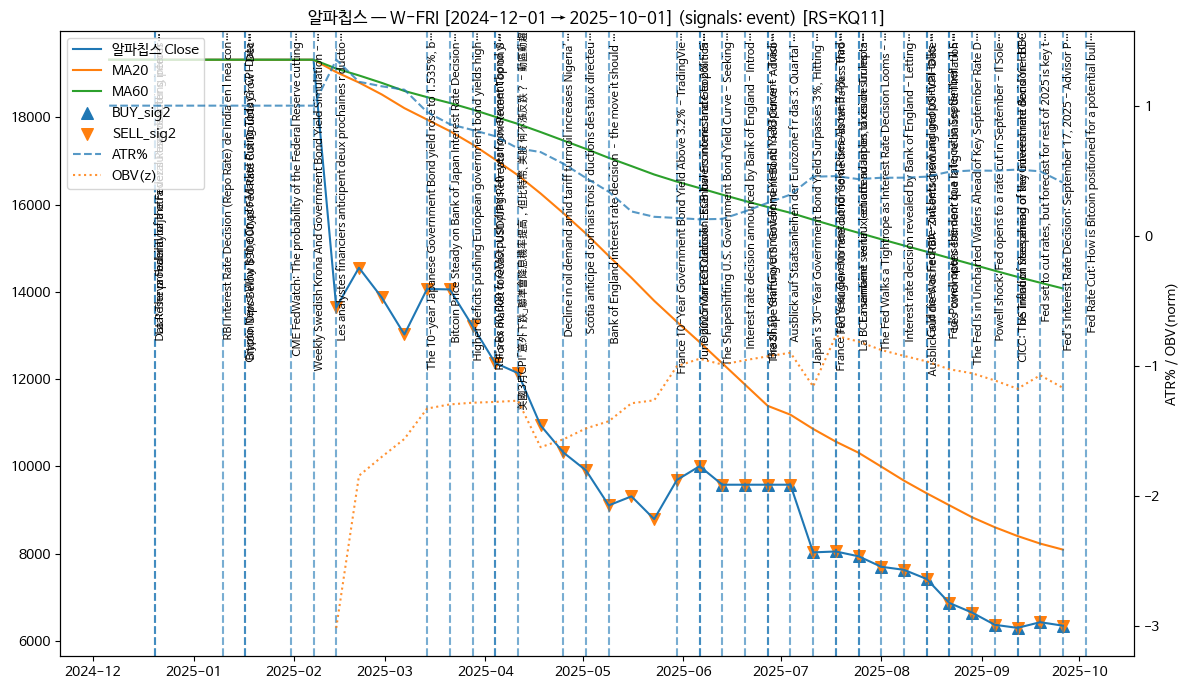

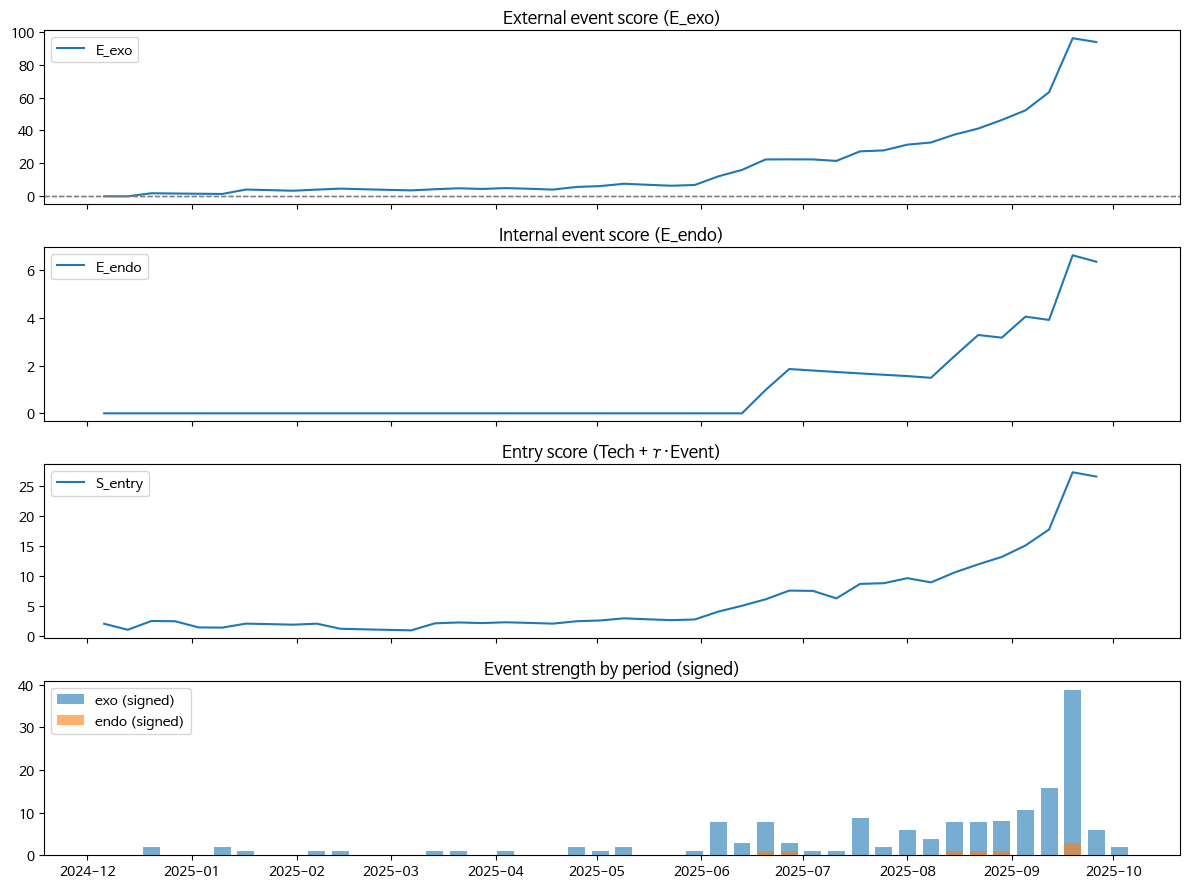

In [123]:
# 2) Event-only 정책 (이벤트가 없으면 의도적으로 거래 없음)
params = EventRuleParams(theta_on=0.10, tau_buy=4, gamma=0.5, beta=0.5)
mix = plot_strategy_with_events(
    "117670", name="알파칩스",
    basis="W-FRI",
    events_df=events, params=params,
    signal_type="event",
    start_date="2024-12-01", end_date="2025-10-01",
    warmup_days=120,
    # ▶ 메인 차트에 겹쳐서 보기
    overlay_atr=True,
    overlay_obv="zscore",   # "minmax"도 가능
    obv_window=60,
    # 기존 보조패널은 끄기(원하면 켜도 됨)
    show_obv=False, show_atr=False, show_rs=False
)



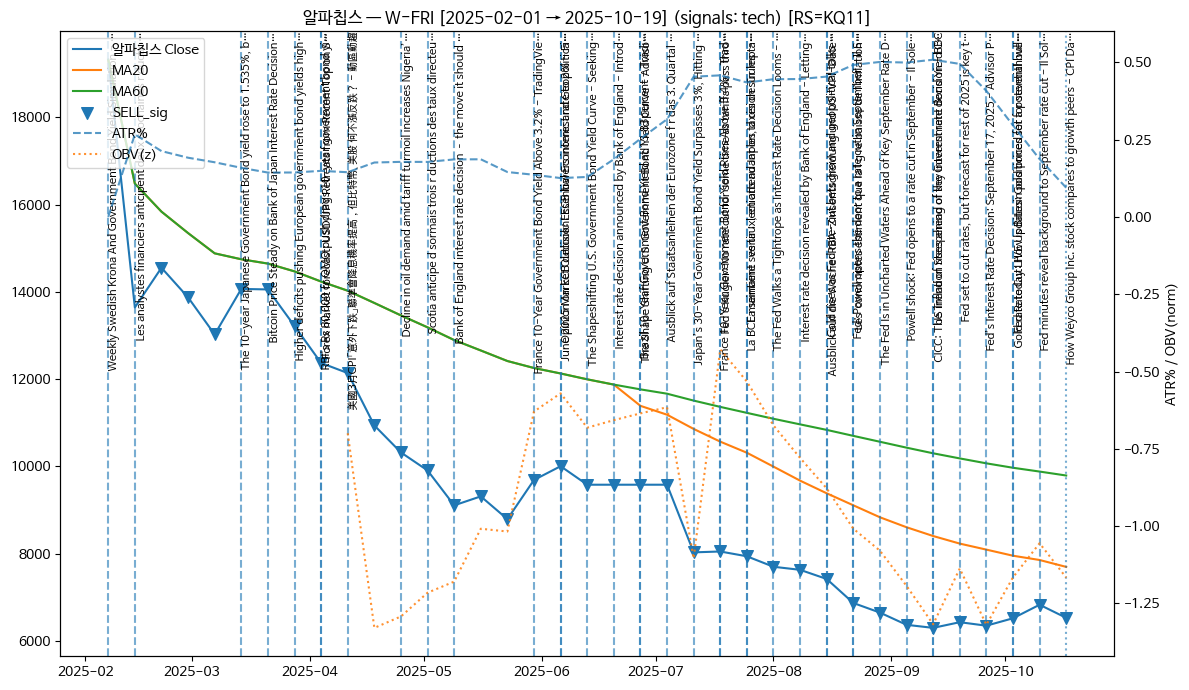

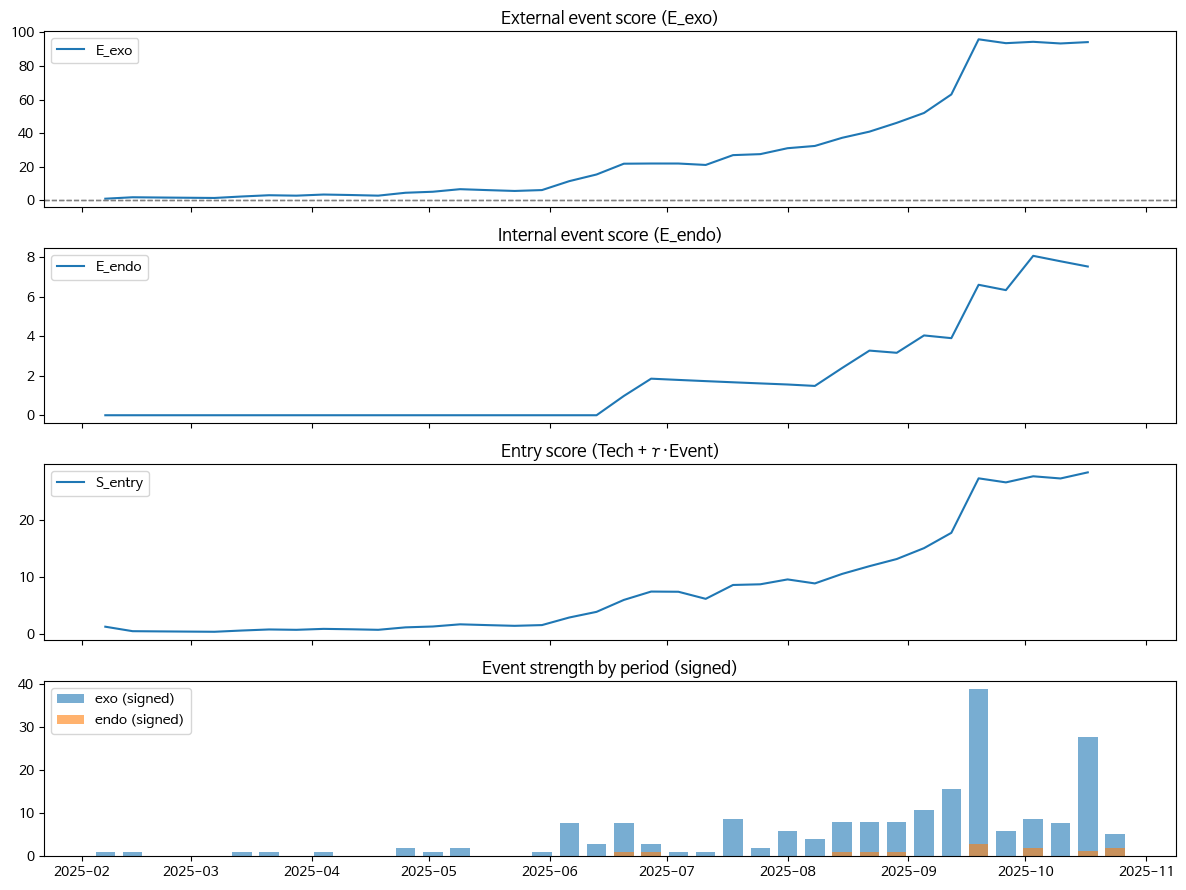

In [120]:
mix = plot_strategy_with_events("117670", name="알파칩스",
                                basis="W-FRI",
                                events_df=events, params=params,
                                signal_type="tech",
                                start_date="2025-02-01", end_date="2025-10-19")

In [91]:

# 3) 백테스트 (No-events)
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=False,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True, atr_floor=0.01, risk_scale=1.0,
    atr_stop_mult=None
)
bt_perf

{'CAGR': 0.0,
 'Sharpe': 0.0,
 'MaxDD': 0.0,
 '#Trades': 0,
 'WinRate': 0.0,
 'AnnVol': 0.0,
 'LastEquity': 1.0}

In [88]:

# 3) 백테스트 (Event-only)
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True, atr_floor=0.01, risk_scale=1.0,
    atr_stop_mult=None
)
bt_perf

{'CAGR': nan,
 'Sharpe': 0.0,
 'MaxDD': -0.0014999999999999458,
 '#Trades': 11,
 'WinRate': 0.1,
 'AnnVol': nan,
 'LastEquity': nan}

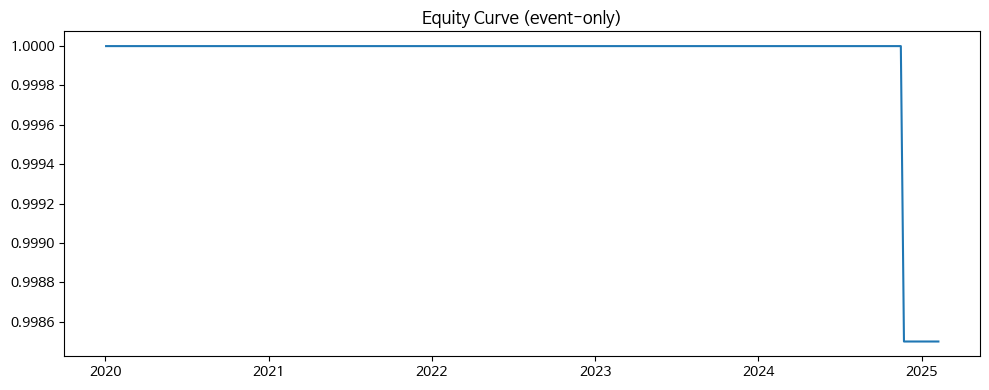

In [89]:
plt.figure(figsize=(10,4)); plt.plot(bt_res.index, bt_res["equity"]); plt.title("Equity Curve (event-only)"); plt.tight_layout(); plt.show()


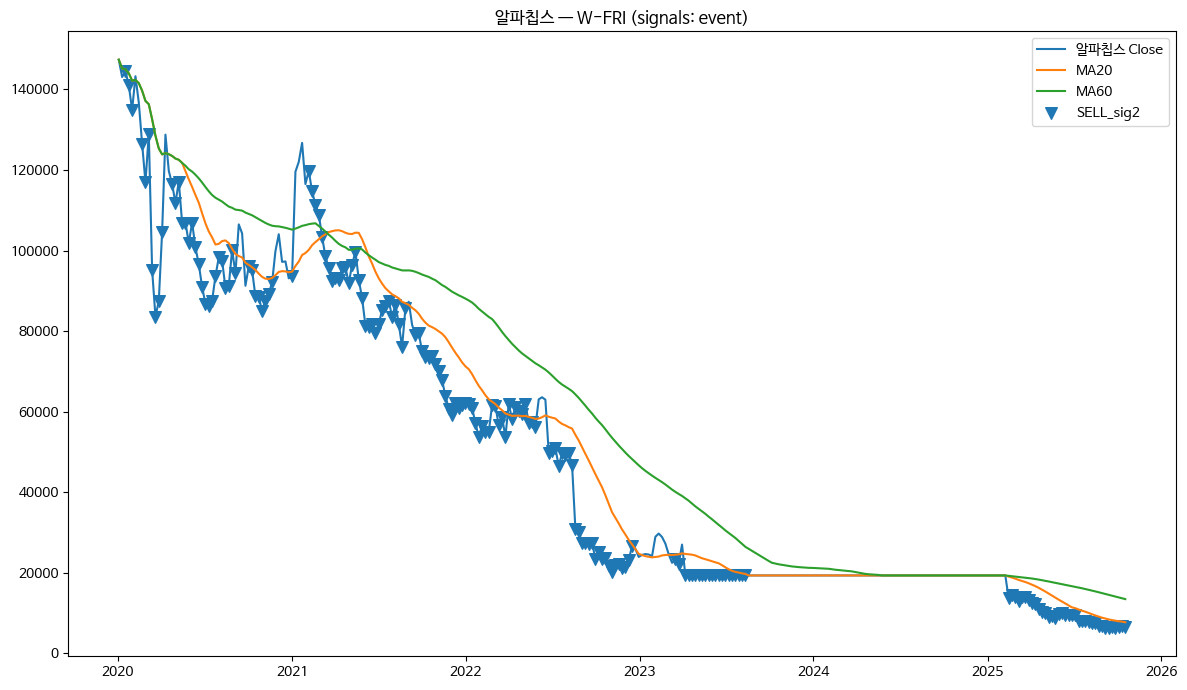

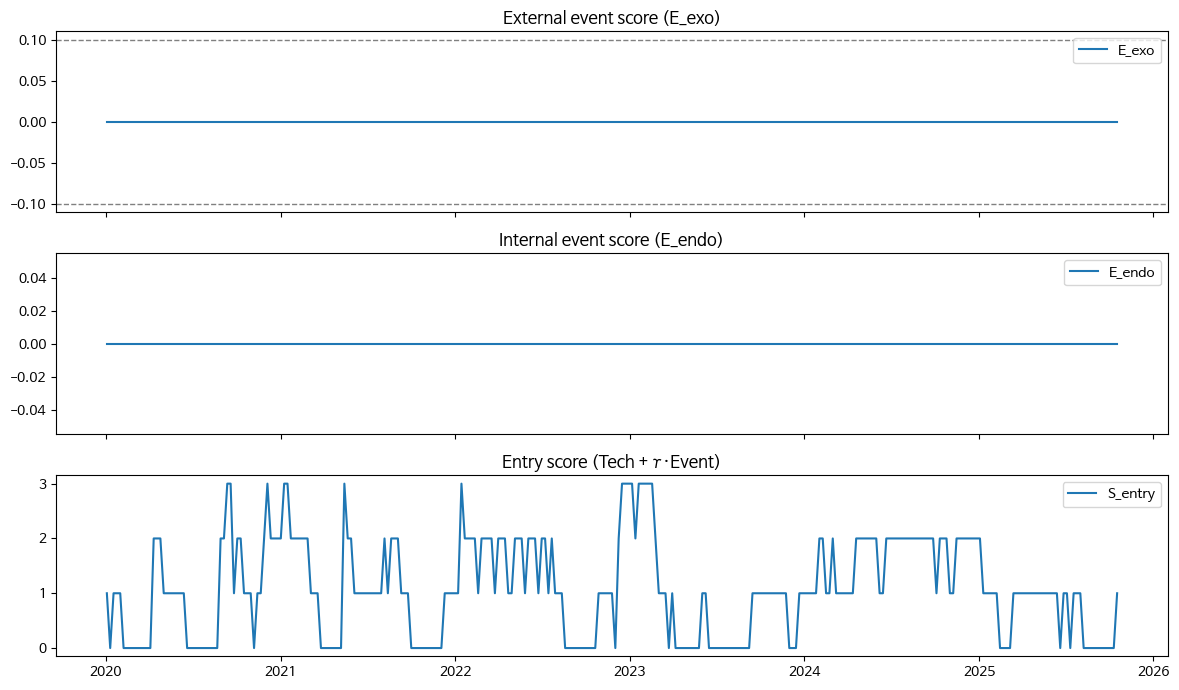

{'CAGR': 0.0,
 'Sharpe': 0.0,
 'MaxDD': 0.0,
 '#Trades': 0,
 'WinRate': 0.0,
 'AnnVol': 0.0,
 'LastEquity': 1.0}

In [90]:

# (B) 기술 실험 — 사용자가 명시적으로 허용할 때만
mix_tech = plot_strategy_with_events("117670", name="알파칩스",
                                basis="W-FRI", rs_index_code="KQ11",
                                events_df=None, params=EventRuleParams(m1=20, m2=60),
                                use_imputed=True, signal_type="tech",
                                show_agg_bar=False)

bt_res2, bt_perf2 = simulate_backtest_from_mix(
    mix_tech, basis="W-FRI", exec_at="open",
    use_event_signals=False,  # 기술 신호
    fee_bps=10, slippage_bps=5, use_position_sizing=True
)
bt_perf2


In [ ]:
plt.figure(figsize=(10,4)); plt.plot(bt_res2.index, bt_res2["equity"]); plt.title("Equity Curve (tech-only)"); plt.tight_layout(); plt.show()


# 멀티 비교 예시(옵션)

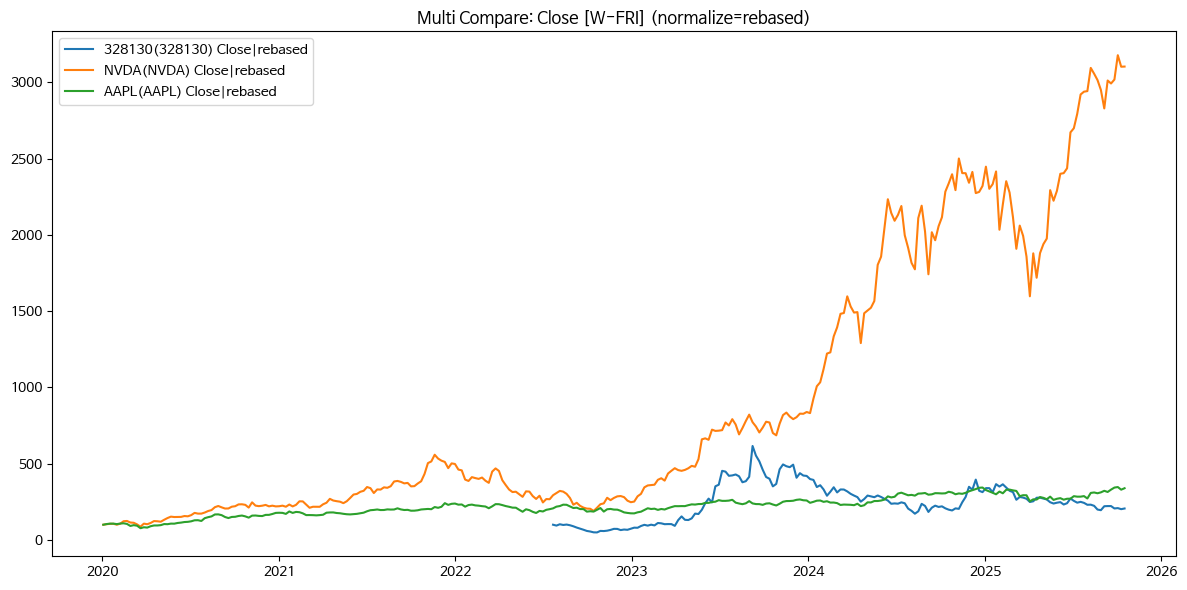

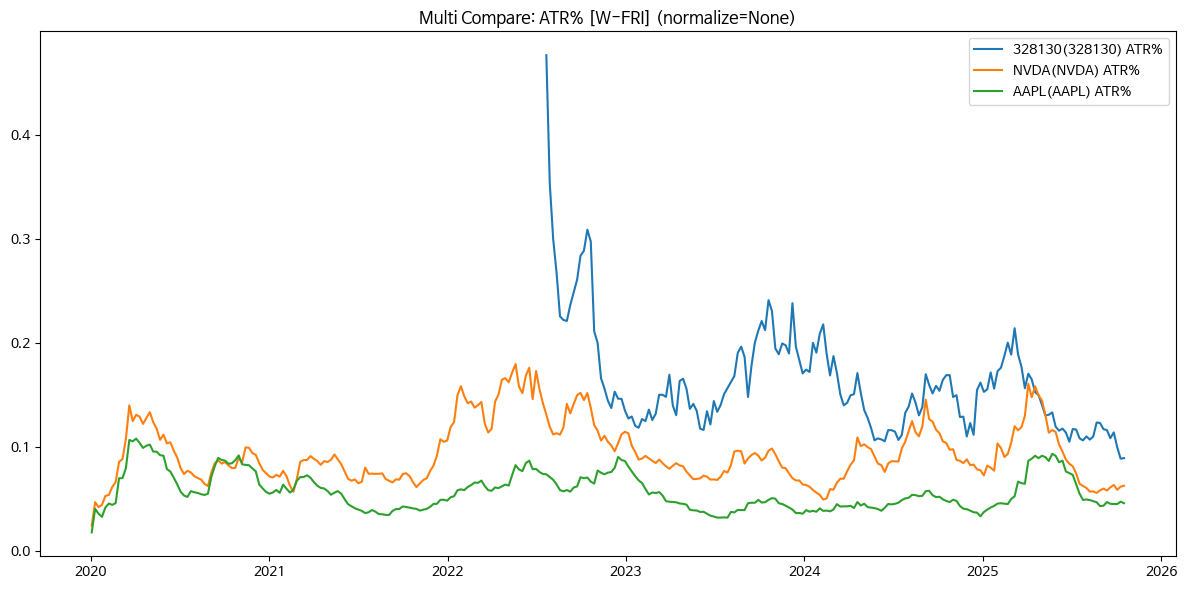

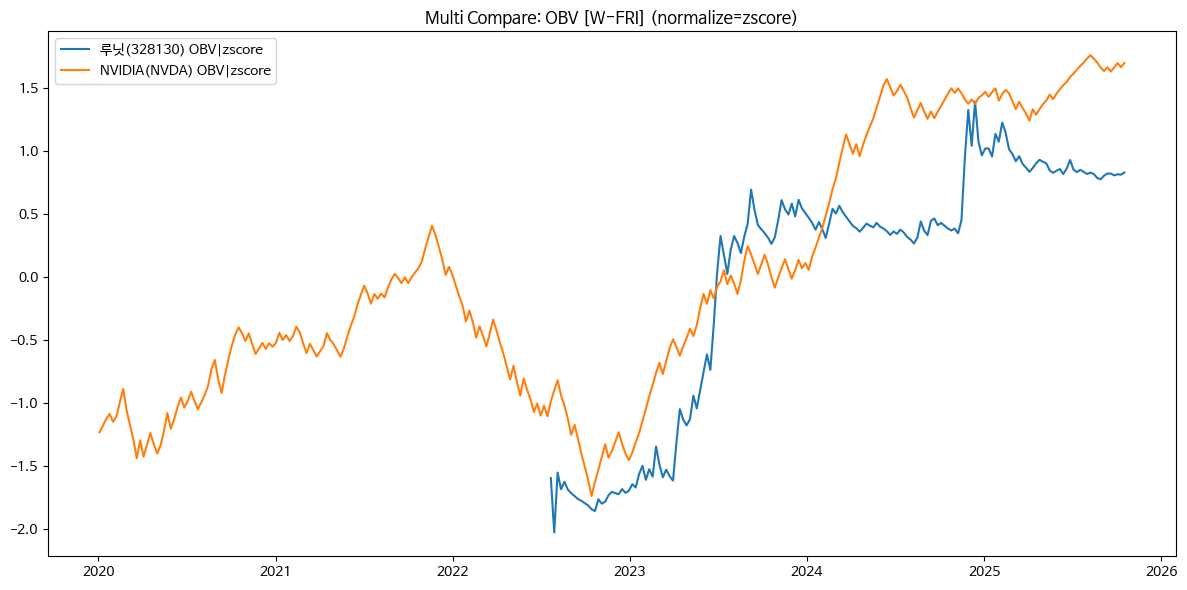

In [105]:
# 가격 리베이스 비교
plot_multi_compare(["328130","NVDA","AAPL"], basis="W-FRI", field="Close", normalize="rebased")
# 변동성(ATR%) 비교
plot_multi_compare(["328130","NVDA","AAPL"], basis="W-FRI", field="ATR%", normalize=None)
# OBV z-score 비교
plot_multi_compare({"루닛":"328130","NVIDIA":"NVDA"}, basis="W-FRI", field="OBV", normalize="zscore")


# 이벤트 강도를 줄이기 위한 방식(주단위 유지)

A) “저소음(Lo-noise) 주간” 프리셋

주 단위 유지하면서 강한 이벤트만 남긴다.

basis="W-FRI"(그대로)

이벤트 필터: quantile 97% 이상만 표시

이벤트 영향 약화: gamma ↓, 반감기 ↓

리스크 온/오프 문턱 강화

In [ ]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.30,            # 이벤트 반영도 축소
    tau_buy=5,             # 진입 더 보수적
    theta_on=0.15,         # 리스크온 조건 강화
    theta_off=-0.15,       # 리스크오프 조건 강화
    half_life_exo=5,       # 이벤트 잔향 빨리 소멸
    half_life_endo=10
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="quantile",  # 핵심: 상위 분위수만 표시
    event_q=0.97,                  # 97% 이상만 남김
    show_agg_bar=True
)


B) “2주 압축(2W)” 프리셋

주간이 여전히 복잡하면 2주 단위로 압축.

basis="2W-FRI"

이벤트 필터: Top-K=1 (기간×유형별 1건만)

이벤트 영향 더 약화

In [ ]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.25,
    tau_buy=5,
    theta_on=0.18,
    theta_off=-0.18,
    half_life_exo=4,
    half_life_endo=8
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="2W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk",     # 핵심: 각 기간·유형당 1건
    event_top_k=1,
    show_agg_bar=True
)


C) “월간 핵심(Monthly core)” 프리셋

월 단위로 묶어서 아주 소수의 이벤트만 본다.

basis="M"

이벤트 필터: Top-K=1 또는 quantile=0.99

이벤트 영향 최소화

In [ ]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.20,
    tau_buy=6,
    theta_on=0.20,
    theta_off=-0.20,
    half_life_exo=3,
    half_life_endo=6
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="M", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk",   # 또는 "quantile", event_q=0.99
    event_top_k=1,
    show_agg_bar=True
)
